#1. Date Feature Engineering
**Date feature engineering is performed to extract meaningful information from the transaction date. Features such as year, month, and day of the week help capture seasonal and temporal patterns in sales. An additional feature, is_month_end, is created to identify increased sales activity typically observed towards the end of the month.**

In [1]:
#1. File Uploading
from google.colab import files
uploaded = files.upload()

Saving q3_retail_promotions.csv to q3_retail_promotions.csv


In [2]:
#2. Loading Data
import pandas as pd

df3 = pd.read_csv('q3_retail_promotions.csv')

In [3]:
#3. Converting to datetime
df3['transaction_date'] = pd.to_datetime(df3['transaction_date'])

In [4]:
#4. Extracting features
df3['year'] = df3['transaction_date'].dt.year
df3['month'] = df3['transaction_date'].dt.month
df3['day_of_week'] = df3['transaction_date'].dt.dayofweek

In [5]:
#5. Output
df3['is_month_end'] = df3['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

In [6]:
df3.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


#2. Temporal Train-Test Split
**In time-based data, a random train-test split can lead to data leakage, where information from the future is used to predict the past. This results in overly optimistic model performance. Therefore, the data is sorted by transaction date and split chronologically, using the earliest 80% for training and the most recent 20% for testing. This approach better reflects real-world scenarios where models are trained on past data to predict future outcomes.**

In [7]:
#1. Sorting by date
df3 = df3.sort_values(by='transaction_date')

In [8]:
#2. Define split index (80%)
split_index = int(len(df3) * 0.8)

In [9]:
#3. Spliting data
train_df = df3.iloc[:split_index]
test_df = df3.iloc[split_index:]

In [10]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (960, 13)
Test shape: (240, 13)


In [11]:
print("Train last date:", train_df['transaction_date'].max())
print("Test first date:", test_df['transaction_date'].min())

Train last date: 2024-06-11 00:00:00
Test first date: 2024-06-12 00:00:00


#3. Preprocessing Pipeline
**A preprocessing pipeline is used to automate data transformation steps in a structured and reproducible manner. Categorical variables are converted into numerical form using one-hot encoding, while numerical features are standardised using StandardScaler to ensure uniform scaling. The pipeline is fit only on the training data and then applied to both training and test sets to prevent data leakage.**

In [12]:
#1. Separate features and target
X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

In [13]:
#2. Defining column groups
categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols = [
    'store_id', 'competition_density',
    'year', 'month', 'day_of_week',
    'is_month_end', 'is_weekend', 'is_festival'
]

In [14]:
#3. Importing tools
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [15]:
#4. Creating ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [16]:
#5. Fit ONLY on training data
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['promotion_type', 'location_type',
                                  'store_size']),
                                ('num', StandardScaler(),
                                 ['store_id', 'competition_density', 'year',
                                  'month', 'day_of_week', 'is_month_end',
                                  'is_weekend', 'is_festival'])])

In [17]:
#6. Transform both datasets
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [18]:
#7. Results
print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (960, 19)
Processed test shape: (240, 19)


#4. Model Training and Evaluation
**Two regression models are trained using a pipeline that includes preprocessing and model training steps. Linear Regression serves as a baseline model, while Random Forest is used as a more advanced model. Model performance is evaluated using RMSE and MAE. A parity plot is used to visually compare predicted and actual values. Feature importance from the Random Forest model helps identify the most influential factors affecting sales.**

In [20]:
#1. Importing Models and Metrics and Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

In [21]:
#2. Creating Pipelines
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [22]:
#3. Train Models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end', 'is_weekend',
                                                   'is_festival'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [24]:
#4. Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

In [25]:
#5. Evaluation (RMSE + MAE)
# Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Linear Regression → RMSE:", rmse_lr, " MAE:", mae_lr)
print("Random Forest → RMSE:", rmse_rf, " MAE:", mae_rf)

Linear Regression → RMSE: 27.121451164890622  MAE: 21.052926674588402
Random Forest → RMSE: 30.81274248721352  MAE: 24.214958333333335


#PARITY PLOTS

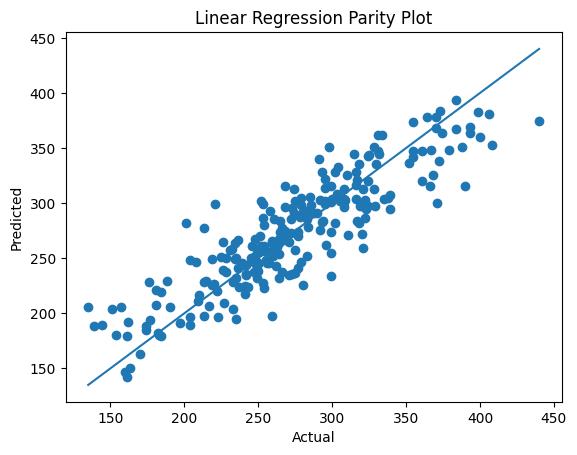

In [26]:
#6. Linear Regression Plot
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Parity Plot")
plt.show()

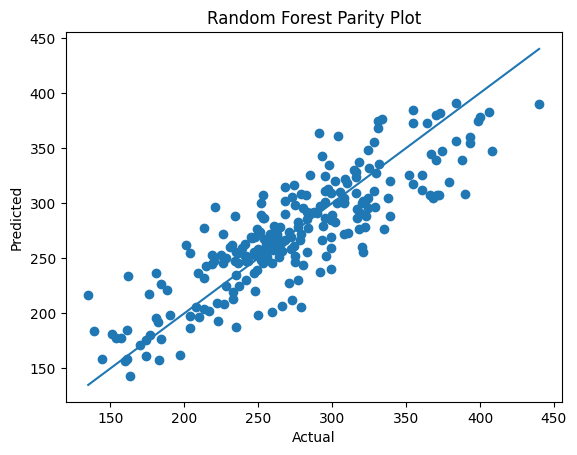

In [27]:
#7. Random Forest Plot
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Parity Plot")
plt.show()

In [28]:
#8. Extract Feature Names
feature_names = preprocessor.get_feature_names_out()

In [29]:
#9. Get Importance
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(5)

,feature,importance
18,num__is_festival,0.173420
10,cat__store_size_small,0.166905
7,cat__location_type_urban,0.109239
15,num__day_of_week,0.084720
17,num__is_weekend,0.062545


The Random Forest model provides feature importance scores that indicate the most influential factors affecting sales. Based on the results, the top features are:

is_festival (highest importance), suggesting that festival periods significantly increase sales
store_size_small, indicating that smaller stores show distinct sales patterns
location_type_urban, showing that urban stores have a strong impact on sales performance
day_of_week, reflecting variation in sales across different days
is_weekend, indicating higher or different customer activity during weekends

These results suggest that temporal factors (festival, weekend, day of week) and store characteristics (size and location) play a crucial role in determining the number of items sold.

Overall, the Random Forest model captures these patterns effectively, making it more suitable than Linear Regression for this problem.